# Handwritten Multi-Digit Recognition with CTC

## Goal

This notebook trains a neural network to read variable-length sequences of handwritten digits.

Each image contains between two and five MNIST digits placed from left to right on a larger canvas.

The model must predict the complete digit sequence without receiving:

- character bounding boxes
- digit segmentation points
- one output head for each character position
- the sequence length during inference

## Example

Input image:

`[ handwritten image containing 5 0 7 3 ]`

Target sequence:

`5073`

## Model architecture

The model contains:

1. A convolutional neural network that extracts visual features
2. A bidirectional LSTM that processes features from left to right and right to left
3. A character classifier applied at every horizontal time step
4. CTC loss for alignment-free sequence learning

## CTC output symbols

The output vocabulary contains:

- one blank symbol
- digits 0 through 9

CTC converts frame-level outputs into a sequence by:

1. Removing repeated consecutive predictions
2. Removing blank symbols

For example:

`blank, 5, 5, blank, 0, 0, blank, 7`

becomes:

`507`

## Main evaluation metrics

- Exact sequence accuracy
- Character Error Rate, CER
- Sequence-length accuracy
- Average edit distance
- Substitution count
- Insertion count
- Deletion count

## Additional analysis

- Performance by sequence length
- Performance on adjacent repeated digits
- Random prediction examples
- Worst prediction examples
- CTC alignment probability visualisation
- Tight-spacing robustness
- Wide-spacing robustness
- Noise robustness

## Main question

Can a neural network learn to recognise an entire handwritten sequence without explicit character segmentation?

In [1]:
import copy
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
    Subset
)

from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torchvision.transforms.functional import resize
from torchvision.transforms import InterpolationMode

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

CANVAS_HEIGHT = 32
CANVAS_WIDTH = 192

MINIMUM_SEQUENCE_LENGTH = 2
MAXIMUM_SEQUENCE_LENGTH = 5

TRAINING_SEQUENCES = 15_000
VALIDATION_SEQUENCES = 3_000
TEST_SEQUENCES = 4_000

BATCH_SIZE = 64

BLANK_TOKEN = 0
NUMBER_OF_OUTPUT_CLASSES = 11


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


set_seed(RANDOM_STATE)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)
print("PyTorch version:", torch.__version__)

Device: cuda
PyTorch version: 2.5.1+cu124


In [2]:
full_training_mnist = MNIST(
    root="data",
    train=True,
    transform=ToTensor(),
    download=True
)

test_mnist = MNIST(
    root="data",
    train=False,
    transform=ToTensor(),
    download=True
)

print(
    "Original MNIST training images:",
    len(full_training_mnist)
)

print(
    "Original MNIST test images:",
    len(test_mnist)
)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [01:27<00:00, 114kB/s] 


Extracting data\MNIST\raw\train-images-idx3-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 140kB/s]


Extracting data\MNIST\raw\train-labels-idx1-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.13MB/s]


Extracting data\MNIST\raw\t10k-images-idx3-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 3.02MB/s]

Extracting data\MNIST\raw\t10k-labels-idx1-ubyte.gz to data\MNIST\raw

Original MNIST training images: 60000
Original MNIST test images: 10000


In [3]:
split_generator = torch.Generator().manual_seed(
    RANDOM_STATE
)

shuffled_training_indices = torch.randperm(
    len(full_training_mnist),
    generator=split_generator
).tolist()

training_source_indices = (
    shuffled_training_indices[:50_000]
)

validation_source_indices = (
    shuffled_training_indices[50_000:]
)

training_source = Subset(
    full_training_mnist,
    training_source_indices
)

validation_source = Subset(
    full_training_mnist,
    validation_source_indices
)

print(
    "Training source images:",
    len(training_source)
)

print(
    "Validation source images:",
    len(validation_source)
)

print(
    "Test source images:",
    len(test_mnist)
)

Training source images: 50000
Validation source images: 10000
Test source images: 10000


## Source-data 

The original MNIST data was divided into:

- 50,000 training source images
- 10,000 validation source images
- 10,000 official test source images

The final test sequences were generated only from the official MNIST test collection.

This prevented exact handwritten images from appearing in both training and test sequences, even though all images belonged to the same MNIST digit domain.

In [4]:
def crop_digit_foreground(
    image,
    threshold=0.05
):
    foreground_mask = (
        image[0] > threshold
    )

    if not foreground_mask.any():
        return image

    foreground_rows = torch.where(
        foreground_mask.any(dim=1)
    )[0]

    foreground_columns = torch.where(
        foreground_mask.any(dim=0)
    )[0]

    top = int(
        foreground_rows.min()
    )

    bottom = int(
        foreground_rows.max()
    ) + 1

    left = int(
        foreground_columns.min()
    )

    right = int(
        foreground_columns.max()
    ) + 1

    return image[
        :,
        top:bottom,
        left:right
    ]

In [5]:
class MultiDigitMNISTDataset(Dataset):
    def __init__(
        self,
        source_dataset,
        number_of_sequences,
        canvas_height=32,
        canvas_width=192,
        minimum_sequence_length=2,
        maximum_sequence_length=5,
        minimum_spacing=2,
        maximum_spacing=6,
        minimum_digit_height=20,
        maximum_digit_height=28,
        noise_standard_deviation=0.03,
        base_seed=10_000
    ):
        self.source_dataset = source_dataset
        self.number_of_sequences = (
            number_of_sequences
        )

        self.canvas_height = canvas_height
        self.canvas_width = canvas_width

        self.minimum_sequence_length = (
            minimum_sequence_length
        )

        self.maximum_sequence_length = (
            maximum_sequence_length
        )

        self.minimum_spacing = (
            minimum_spacing
        )

        self.maximum_spacing = (
            maximum_spacing
        )

        self.minimum_digit_height = (
            minimum_digit_height
        )

        self.maximum_digit_height = (
            maximum_digit_height
        )

        self.noise_standard_deviation = (
            noise_standard_deviation
        )

        self.base_seed = base_seed

    def __len__(self):
        return self.number_of_sequences

    def __getitem__(self, index):
        rng = np.random.default_rng(
            self.base_seed + index
        )

        sequence_length = int(
            rng.integers(
                self.minimum_sequence_length,
                self.maximum_sequence_length + 1
            )
        )

        source_indices = rng.integers(
            0,
            len(self.source_dataset),
            size=sequence_length
        )

        resized_digits = []
        digit_labels = []

        for source_index in source_indices:
            image, digit_label = (
                self.source_dataset[
                    int(source_index)
                ]
            )

            digit_crop = crop_digit_foreground(
                image
            )

            original_height = (
                digit_crop.shape[-2]
            )

            original_width = (
                digit_crop.shape[-1]
            )

            target_height = int(
                rng.integers(
                    self.minimum_digit_height,
                    self.maximum_digit_height + 1
                )
            )

            aspect_ratio = (
                original_width
                / max(original_height, 1)
            )

            horizontal_variation = float(
                rng.uniform(0.85, 1.15)
            )

            target_width = int(
                round(
                    target_height
                    * aspect_ratio
                    * horizontal_variation
                )
            )

            target_width = int(
                np.clip(
                    target_width,
                    8,
                    22
                )
            )

            resized_digit = resize(
                digit_crop,
                size=[
                    target_height,
                    target_width
                ],
                interpolation=
                    InterpolationMode.BILINEAR,
                antialias=True
            )

            contrast = float(
                rng.uniform(0.75, 1.00)
            )

            resized_digit = (
                resized_digit * contrast
            )

            resized_digits.append(
                resized_digit
            )

            digit_labels.append(
                int(digit_label)
            )

        if sequence_length > 1:
            spacing_values = rng.integers(
                self.minimum_spacing,
                self.maximum_spacing + 1,
                size=sequence_length - 1
            )
        else:
            spacing_values = np.array(
                [],
                dtype=int
            )

        digit_widths = [
            digit.shape[-1]
            for digit in resized_digits
        ]

        total_sequence_width = (
            sum(digit_widths)
            + int(spacing_values.sum())
        )

        available_horizontal_space = (
            self.canvas_width
            - total_sequence_width
        )

        if available_horizontal_space < 0:
            raise ValueError(
                "Generated sequence exceeds "
                "the canvas width."
            )

        left_position = int(
            rng.integers(
                0,
                available_horizontal_space + 1
            )
        )

        canvas = torch.zeros(
            (
                1,
                self.canvas_height,
                self.canvas_width
            ),
            dtype=torch.float32
        )

        current_left = left_position

        for digit_index, digit in enumerate(
            resized_digits
        ):
            digit_height = digit.shape[-2]
            digit_width = digit.shape[-1]

            maximum_top = (
                self.canvas_height
                - digit_height
            )

            top_position = int(
                rng.integers(
                    0,
                    maximum_top + 1
                )
            )

            existing_region = canvas[
                :,
                top_position:
                    top_position
                    + digit_height,
                current_left:
                    current_left
                    + digit_width
            ]

            canvas[
                :,
                top_position:
                    top_position
                    + digit_height,
                current_left:
                    current_left
                    + digit_width
            ] = torch.maximum(
                existing_region,
                digit
            )

            current_left += digit_width

            if (
                digit_index
                < sequence_length - 1
            ):
                current_left += int(
                    spacing_values[
                        digit_index
                    ]
                )

        if (
            self.noise_standard_deviation
            > 0
        ):
            noise = torch.tensor(
                rng.normal(
                    loc=0.0,
                    scale=
                        self.noise_standard_deviation,
                    size=canvas.shape
                ),
                dtype=torch.float32
            )

            canvas = canvas + noise

        canvas = canvas.clamp(0, 1)

        target_tokens = torch.tensor(
            [
                digit + 1
                for digit in digit_labels
            ],
            dtype=torch.long
        )

        target_text = "".join(
            str(digit)
            for digit in digit_labels
        )

        return (
            canvas,
            target_tokens,
            target_text
        )

In [6]:
training_dataset = MultiDigitMNISTDataset(
    source_dataset=training_source,
    number_of_sequences=
        TRAINING_SEQUENCES,
    minimum_spacing=2,
    maximum_spacing=6,
    noise_standard_deviation=0.03,
    base_seed=10_000
)

validation_dataset = (
    MultiDigitMNISTDataset(
        source_dataset=
            validation_source,
        number_of_sequences=
            VALIDATION_SEQUENCES,
        minimum_spacing=2,
        maximum_spacing=6,
        noise_standard_deviation=0.03,
        base_seed=20_000
    )
)

test_dataset = MultiDigitMNISTDataset(
    source_dataset=test_mnist,
    number_of_sequences=
        TEST_SEQUENCES,
    minimum_spacing=2,
    maximum_spacing=6,
    noise_standard_deviation=0.03,
    base_seed=30_000
)

print(
    "Training sequences:",
    len(training_dataset)
)

print(
    "Validation sequences:",
    len(validation_dataset)
)

print(
    "Test sequences:",
    len(test_dataset)
)

Training sequences: 15000
Validation sequences: 3000
Test sequences: 4000


## Sequence generation 

The custom dataset generated:

- 15,000 training sequences
- 3,000 validation sequences
- 4,000 test sequences

Each image contained between two and five digits on a 32 × 192 canvas.

Sequence generation varied:

- digit identity
- handwriting example
- sequence length
- digit height and width
- vertical position
- horizontal starting position
- spacing between characters
- stroke contrast
- background noise

The target supplied to the model contained only the ordered digit string. No character locations, segmentation points, or sequence length were given during inference.

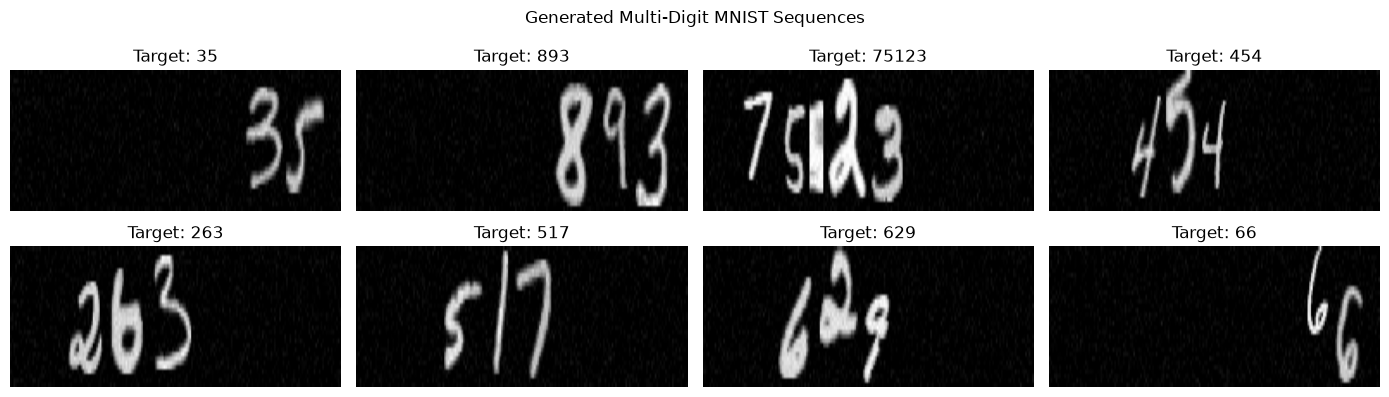

In [7]:
figure, axes = plt.subplots(
    2,
    4,
    figsize=(14, 4)
)

for index, axis in enumerate(
    axes.flatten()
):
    image, _, text = (
        training_dataset[index]
    )

    axis.imshow(
        image.squeeze(),
        cmap="gray",
        vmin=0,
        vmax=1,
        aspect="auto"
    )

    axis.set_title(
        f"Target: {text}"
    )

    axis.axis("off")

plt.suptitle(
    "Generated Multi-Digit MNIST Sequences"
)

plt.tight_layout()
plt.show()

## Generated examples 

The generated scenes contained sequences ranging from two to five digits, including examples such as:

- `35`
- `893`
- `75123`
- `454`
- `263`
- `517`
- `629`
- `66`

The examples showed considerable variation in handwriting style, digit width, vertical alignment, and horizontal placement.

Some characters were thin and narrow, while others occupied much more horizontal space. The repeated sequence `66` also demonstrated that adjacent identical digits could appear.

Because the complete sequence could begin anywhere on the canvas and spacing was not fixed, the model could not rely on predefined character positions.

In [8]:
def ctc_collate_function(batch):
    images = []
    target_sequences = []
    target_lengths = []
    target_texts = []

    for (
        image,
        target_tokens,
        target_text
    ) in batch:
        images.append(image)

        target_sequences.append(
            target_tokens
        )

        target_lengths.append(
            len(target_tokens)
        )

        target_texts.append(
            target_text
        )

    stacked_images = torch.stack(
        images
    )

    concatenated_targets = torch.cat(
        target_sequences
    )

    target_lengths = torch.tensor(
        target_lengths,
        dtype=torch.long
    )

    return (
        stacked_images,
        concatenated_targets,
        target_lengths,
        target_texts
    )

In [9]:
training_loader = DataLoader(
    training_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=ctc_collate_function,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=ctc_collate_function,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=ctc_collate_function,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

In [10]:
(
    batch_images,
    batch_targets,
    batch_target_lengths,
    batch_texts
) = next(iter(training_loader))

print(
    "Image batch shape:",
    batch_images.shape
)

print(
    "Concatenated targets shape:",
    batch_targets.shape
)

print(
    "Target lengths:",
    batch_target_lengths[:10]
)

print(
    "Example target texts:",
    batch_texts[:10]
)

Image batch shape: torch.Size([64, 1, 32, 192])
Concatenated targets shape: torch.Size([226])
Target lengths: tensor([4, 5, 3, 4, 3, 4, 4, 3, 3, 3])
Example target texts: ['3482', '02117', '436', '5812', '476', '0535', '3816', '543', '933', '799']


In [11]:
def levenshtein_alignment(
    true_text,
    predicted_text
):
    true_length = len(true_text)
    predicted_length = len(
        predicted_text
    )

    distance_table = np.zeros(
        (
            true_length + 1,
            predicted_length + 1
        ),
        dtype=int
    )

    operation_table = np.empty(
        (
            true_length + 1,
            predicted_length + 1
        ),
        dtype=object
    )

    for true_index in range(
        1,
        true_length + 1
    ):
        distance_table[
            true_index,
            0
        ] = true_index

        operation_table[
            true_index,
            0
        ] = "deletion"

    for predicted_index in range(
        1,
        predicted_length + 1
    ):
        distance_table[
            0,
            predicted_index
        ] = predicted_index

        operation_table[
            0,
            predicted_index
        ] = "insertion"

    for true_index in range(
        1,
        true_length + 1
    ):
        for predicted_index in range(
            1,
            predicted_length + 1
        ):
            if (
                true_text[true_index - 1]
                == predicted_text[
                    predicted_index - 1
                ]
            ):
                distance_table[
                    true_index,
                    predicted_index
                ] = distance_table[
                    true_index - 1,
                    predicted_index - 1
                ]

                operation_table[
                    true_index,
                    predicted_index
                ] = "match"

            else:
                substitution_cost = (
                    distance_table[
                        true_index - 1,
                        predicted_index - 1
                    ]
                    + 1
                )

                deletion_cost = (
                    distance_table[
                        true_index - 1,
                        predicted_index
                    ]
                    + 1
                )

                insertion_cost = (
                    distance_table[
                        true_index,
                        predicted_index - 1
                    ]
                    + 1
                )

                candidate_costs = [
                    substitution_cost,
                    deletion_cost,
                    insertion_cost
                ]

                best_operation_index = int(
                    np.argmin(
                        candidate_costs
                    )
                )

                distance_table[
                    true_index,
                    predicted_index
                ] = candidate_costs[
                    best_operation_index
                ]

                operation_table[
                    true_index,
                    predicted_index
                ] = [
                    "substitution",
                    "deletion",
                    "insertion"
                ][best_operation_index]

    true_index = true_length
    predicted_index = predicted_length

    operation_counts = {
        "match": 0,
        "substitution": 0,
        "deletion": 0,
        "insertion": 0
    }

    while (
        true_index > 0
        or predicted_index > 0
    ):
        operation = operation_table[
            true_index,
            predicted_index
        ]

        operation_counts[
            operation
        ] += 1

        if operation in [
            "match",
            "substitution"
        ]:
            true_index -= 1
            predicted_index -= 1

        elif operation == "deletion":
            true_index -= 1

        elif operation == "insertion":
            predicted_index -= 1

    operation_counts[
        "edit_distance"
    ] = int(
        distance_table[
            true_length,
            predicted_length
        ]
    )

    return operation_counts

In [12]:
def calculate_sequence_metrics(
    true_texts,
    predicted_texts
):
    exact_matches = 0
    correct_lengths = 0

    total_characters = 0
    total_edits = 0

    total_substitutions = 0
    total_insertions = 0
    total_deletions = 0

    for true_text, predicted_text in zip(
        true_texts,
        predicted_texts
    ):
        exact_matches += int(
            true_text == predicted_text
        )

        correct_lengths += int(
            len(true_text)
            == len(predicted_text)
        )

        alignment = (
            levenshtein_alignment(
                true_text,
                predicted_text
            )
        )

        total_characters += len(
            true_text
        )

        total_edits += alignment[
            "edit_distance"
        ]

        total_substitutions += (
            alignment["substitution"]
        )

        total_insertions += (
            alignment["insertion"]
        )

        total_deletions += (
            alignment["deletion"]
        )

    number_of_sequences = len(
        true_texts
    )

    return {
        "exact_sequence_accuracy":
            exact_matches
            / number_of_sequences,

        "character_error_rate":
            total_edits
            / max(total_characters, 1),

        "length_accuracy":
            correct_lengths
            / number_of_sequences,

        "mean_edit_distance":
            total_edits
            / number_of_sequences,

        "substitutions":
            total_substitutions,

        "insertions":
            total_insertions,

        "deletions":
            total_deletions
    }

In [13]:
training_source_labels = (
    full_training_mnist.targets[
        training_source_indices
    ]
    .numpy()
)

most_common_digit = Counter(
    training_source_labels
).most_common(1)[0][0]

print(
    "Most common training digit:",
    most_common_digit
)

Most common training digit: 1


In [14]:
baseline_true_texts = []

for index in range(
    len(test_dataset)
):
    _, _, target_text = (
        test_dataset[index]
    )

    baseline_true_texts.append(
        target_text
    )

baseline_predicted_texts = [
    str(most_common_digit)
    * len(true_text)
    for true_text in baseline_true_texts
]

baseline_metrics = (
    calculate_sequence_metrics(
        baseline_true_texts,
        baseline_predicted_texts
    )
)

baseline_metrics

{'exact_sequence_accuracy': 0.0035,
 'character_error_rate': 0.8840799249801631,
 'length_accuracy': 1.0,
 'mean_edit_distance': 3.064,
 'substitutions': 12256,
 'insertions': 0,
 'deletions': 0}

## Sequence baseline 

The most common digit in the training source collection was Digit 1.

The oracle-length baseline was given the correct sequence length and predicted Digit 1 at every position.

It achieved:

- Exact sequence accuracy: 0.0035
- Character Error Rate: 0.8841
- Length accuracy: 1.0000
- Mean edit distance: 3.0640
- Substitutions: 12,256
- Insertions: 0
- Deletions: 0

The perfect length accuracy was artificial because the true target length was provided to the baseline.

Despite receiving this advantage, the baseline recognised only 0.35% of complete sequences. Its CER of 88.41% shows that digit-frequency information alone was almost useless for reading the actual images.

In [15]:
class ConvolutionBlock(nn.Module):
    def __init__(
        self,
        input_channels,
        output_channels,
        pooling
    ):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                input_channels,
                output_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(
                output_channels
            ),
            nn.ReLU(),
            nn.MaxPool2d(pooling)
        )

    def forward(self, images):
        return self.block(images)

In [16]:
class MultiDigitCTCModel(nn.Module):
    def __init__(
        self,
        hidden_size=128,
        number_of_lstm_layers=2
    ):
        super().__init__()

        self.cnn = nn.Sequential(
            ConvolutionBlock(
                1,
                32,
                pooling=(2, 2)
            ),

            ConvolutionBlock(
                32,
                64,
                pooling=(2, 2)
            ),

            ConvolutionBlock(
                64,
                128,
                pooling=(2, 1)
            ),

            nn.Conv2d(
                128,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.sequence_model = nn.LSTM(
            input_size=128,
            hidden_size=hidden_size,
            num_layers=
                number_of_lstm_layers,
            dropout=0.20,
            bidirectional=True
        )

        self.character_classifier = nn.Linear(
            hidden_size * 2,
            NUMBER_OF_OUTPUT_CLASSES
        )

    def forward(self, images):
        feature_maps = self.cnn(images)

        feature_maps = (
            F.adaptive_avg_pool2d(
                feature_maps,
                output_size=(
                    1,
                    feature_maps.shape[-1]
                )
            )
        )

        feature_sequence = (
            feature_maps
            .squeeze(2)
            .permute(2, 0, 1)
        )

        sequence_features, _ = (
            self.sequence_model(
                feature_sequence
            )
        )

        character_logits = (
            self.character_classifier(
                sequence_features
            )
        )

        return character_logits

In [17]:
model = MultiDigitCTCModel().to(
    device
)

with torch.no_grad():
    example_logits = model(
        batch_images[:4].to(device)
    )

print(
    "CTC logits shape:",
    example_logits.shape
)

print(
    "Available time steps:",
    example_logits.shape[0]
)

print(
    "Batch size:",
    example_logits.shape[1]
)

print(
    "Output classes:",
    example_logits.shape[2]
)

CTC logits shape: torch.Size([48, 4, 11])
Available time steps: 48
Batch size: 4
Output classes: 11


In [18]:
def greedy_ctc_decode(
    character_logits
):
    predicted_tokens = (
        character_logits
        .argmax(dim=2)
        .transpose(0, 1)
    )

    decoded_texts = []

    for sequence_tokens in (
        predicted_tokens
    ):
        previous_token = None
        decoded_digits = []

        for token in (
            sequence_tokens.tolist()
        ):
            if (
                token != previous_token
                and token != BLANK_TOKEN
            ):
                decoded_digits.append(
                    str(token - 1)
                )

            previous_token = token

        decoded_texts.append(
            "".join(decoded_digits)
        )

    return decoded_texts

In [19]:
untrained_predictions = (
    greedy_ctc_decode(
        example_logits.cpu()
    )
)

print(
    "Untrained predictions:",
    untrained_predictions
)

Untrained predictions: ['327371313137', '3171237271313737', '3131313131373237313738', '3137131737317373']


In [20]:
ctc_loss_function = nn.CTCLoss(
    blank=BLANK_TOKEN,
    reduction="mean",
    zero_infinity=True
)

In [21]:
@torch.no_grad()
def evaluate_ctc_model(
    model,
    data_loader
):
    model.eval()

    total_loss = 0.0
    total_sequences = 0

    all_true_texts = []
    all_predicted_texts = []

    for (
        images,
        targets,
        target_lengths,
        target_texts
    ) in data_loader:
        images = images.to(device)
        targets_device = targets.to(
            device
        )

        character_logits = model(
            images
        )

        log_probabilities = (
            F.log_softmax(
                character_logits,
                dim=2
            )
        )

        number_of_time_steps = (
            log_probabilities.shape[0]
        )

        input_lengths = torch.full(
            size=(images.shape[0],),
            fill_value=
                number_of_time_steps,
            dtype=torch.long
        )

        loss = ctc_loss_function(
            log_probabilities,
            targets_device,
            input_lengths,
            target_lengths
        )

        batch_size = images.shape[0]

        total_loss += (
            loss.item() * batch_size
        )

        total_sequences += batch_size

        predicted_texts = (
            greedy_ctc_decode(
                character_logits.cpu()
            )
        )

        all_true_texts.extend(
            target_texts
        )

        all_predicted_texts.extend(
            predicted_texts
        )

    metrics = (
        calculate_sequence_metrics(
            all_true_texts,
            all_predicted_texts
        )
    )

    metrics["loss"] = (
        total_loss / total_sequences
    )

    result_rows = []

    for index, (
        true_text,
        predicted_text
    ) in enumerate(
        zip(
            all_true_texts,
            all_predicted_texts
        )
    ):
        alignment = (
            levenshtein_alignment(
                true_text,
                predicted_text
            )
        )

        contains_adjacent_repeat = any(
            true_text[position]
            == true_text[position + 1]
            for position in range(
                len(true_text) - 1
            )
        )

        result_rows.append({
            "dataset_index": index,
            "true_text": true_text,
            "predicted_text":
                predicted_text,
            "true_length":
                len(true_text),
            "predicted_length":
                len(predicted_text),
            "exact_match":
                true_text
                == predicted_text,
            "contains_adjacent_repeat":
                contains_adjacent_repeat,
            **alignment
        })

    prediction_df = pd.DataFrame(
        result_rows
    )

    return {
        "metrics": metrics,
        "prediction_df":
            prediction_df
    }

In [22]:
MAXIMUM_EPOCHS = 10
EARLY_STOPPING_PATIENCE = 3

model = MultiDigitCTCModel().to(
    device
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = (
    torch.optim.lr_scheduler
    .ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=1
    )
)

In [23]:
best_validation_accuracy = -np.inf
best_validation_cer = np.inf

best_model_state = None

epochs_without_improvement = 0

history_rows = []

In [24]:
for epoch in range(
    1,
    MAXIMUM_EPOCHS + 1
):
    model.train()

    running_loss = 0.0
    training_sequences_seen = 0

    for (
        images,
        targets,
        target_lengths,
        _
    ) in training_loader:
        images = images.to(device)

        targets_device = targets.to(
            device
        )

        optimizer.zero_grad()

        character_logits = model(
            images
        )

        log_probabilities = (
            F.log_softmax(
                character_logits,
                dim=2
            )
        )

        number_of_time_steps = (
            log_probabilities.shape[0]
        )

        input_lengths = torch.full(
            size=(images.shape[0],),
            fill_value=
                number_of_time_steps,
            dtype=torch.long
        )

        loss = ctc_loss_function(
            log_probabilities,
            targets_device,
            input_lengths,
            target_lengths
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        batch_size = images.shape[0]

        running_loss += (
            loss.item() * batch_size
        )

        training_sequences_seen += (
            batch_size
        )

    mean_training_loss = (
        running_loss
        / training_sequences_seen
    )

    validation_result = (
        evaluate_ctc_model(
            model,
            validation_loader
        )
    )

    validation_metrics = (
        validation_result["metrics"]
    )

    validation_accuracy = (
        validation_metrics[
            "exact_sequence_accuracy"
        ]
    )

    validation_cer = (
        validation_metrics[
            "character_error_rate"
        ]
    )

    history_rows.append({
        "epoch": epoch,
        "training_loss":
            mean_training_loss,
        "validation_loss":
            validation_metrics["loss"],
        "validation_exact_accuracy":
            validation_accuracy,
        "validation_cer":
            validation_cer,
        "validation_length_accuracy":
            validation_metrics[
                "length_accuracy"
            ],
        "learning_rate":
            optimizer.param_groups[0][
                "lr"
            ]
    })

    print(
        f"Epoch {epoch:02d} | "
        f"Train loss "
        f"{mean_training_loss:.4f} | "
        f"Val loss "
        f"{validation_metrics['loss']:.4f} | "
        f"Exact accuracy "
        f"{validation_accuracy:.4f} | "
        f"CER "
        f"{validation_cer:.4f} | "
        f"Length accuracy "
        f"{validation_metrics['length_accuracy']:.4f}"
    )

    scheduler.step(
        validation_accuracy
    )

    improved = (
        validation_accuracy
        > best_validation_accuracy
        or (
            np.isclose(
                validation_accuracy,
                best_validation_accuracy
            )
            and validation_cer
            < best_validation_cer
        )
    )

    if improved:
        best_validation_accuracy = (
            validation_accuracy
        )

        best_validation_cer = (
            validation_cer
        )

        best_model_state = (
            copy.deepcopy(
                model.state_dict()
            )
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            "Early stopping triggered."
        )
        break

Epoch 01 | Train loss 3.2297 | Val loss 2.2465 | Exact accuracy 0.0000 | CER 1.0000 | Length accuracy 0.0000
Epoch 02 | Train loss 0.6513 | Val loss 0.5931 | Exact accuracy 0.5350 | CER 0.1715 | Length accuracy 0.9777
Epoch 03 | Train loss 0.1105 | Val loss 0.0872 | Exact accuracy 0.9183 | CER 0.0243 | Length accuracy 0.9933
Epoch 04 | Train loss 0.0654 | Val loss 0.1083 | Exact accuracy 0.8960 | CER 0.0311 | Length accuracy 0.9913
Epoch 05 | Train loss 0.0509 | Val loss 0.1202 | Exact accuracy 0.8867 | CER 0.0339 | Length accuracy 0.9957
Epoch 06 | Train loss 0.0260 | Val loss 0.0558 | Exact accuracy 0.9497 | CER 0.0146 | Length accuracy 0.9987
Epoch 07 | Train loss 0.0185 | Val loss 0.0480 | Exact accuracy 0.9580 | CER 0.0122 | Length accuracy 0.9997
Epoch 08 | Train loss 0.0158 | Val loss 0.0534 | Exact accuracy 0.9533 | CER 0.0135 | Length accuracy 0.9983
Epoch 09 | Train loss 0.0124 | Val loss 0.0479 | Exact accuracy 0.9523 | CER 0.0139 | Length accuracy 0.9980
Epoch 10 | Train lo

In [25]:
if best_model_state is not None:
    model.load_state_dict(
        best_model_state
    )

training_history = pd.DataFrame(
    history_rows
)

training_history

,epoch,training_loss,validation_loss,validation_exact_accuracy,validation_cer,validation_length_accuracy,learning_rate
0,1,3.229662,2.246535,0.000000,1.000000,0.000000,0.00100
1,2,0.651254,0.593076,0.535000,0.171532,0.977667,0.00100
2,3,0.110540,0.087193,0.918333,0.024342,0.993333,0.00100
3,4,0.065363,0.108281,0.896000,0.031093,0.991333,0.00100
4,5,0.050861,0.120242,0.886667,0.033945,0.995667,0.00100
5,6,0.026030,0.055757,0.949667,0.014643,0.998667,0.00050
6,7,0.018501,0.047958,0.958000,0.012171,0.999667,0.00050
7,8,0.015835,0.053405,0.953333,0.013502,0.998333,0.00050
8,9,0.012385,0.047880,0.952333,0.013882,0.998000,0.00050
9,10,0.007042,0.041890,0.964333,0.010174,0.999000,0.00025


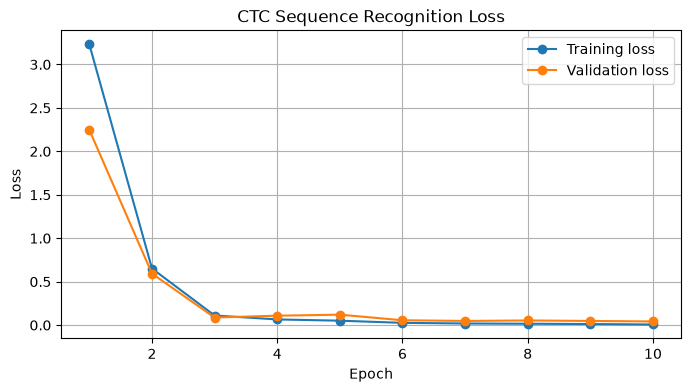

In [26]:
plt.figure(figsize=(8, 4))

plt.plot(
    training_history["epoch"],
    training_history[
        "training_loss"
    ],
    marker="o",
    label="Training loss"
)

plt.plot(
    training_history["epoch"],
    training_history[
        "validation_loss"
    ],
    marker="o",
    label="Validation loss"
)

plt.title("CTC Sequence Recognition Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

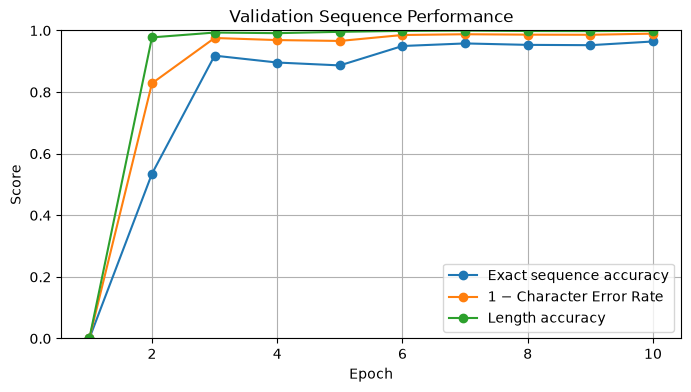

In [27]:
plt.figure(figsize=(8, 4))

plt.plot(
    training_history["epoch"],
    training_history[
        "validation_exact_accuracy"
    ],
    marker="o",
    label="Exact sequence accuracy"
)

plt.plot(
    training_history["epoch"],
    1 - training_history[
        "validation_cer"
    ],
    marker="o",
    label="1 − Character Error Rate"
)

plt.plot(
    training_history["epoch"],
    training_history[
        "validation_length_accuracy"
    ],
    marker="o",
    label="Length accuracy"
)

plt.title("Validation Sequence Performance")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

## Training behaviour 

CTC training showed several distinct stages.

### Epoch 1

The model had not yet learned a useful alignment:

- Training loss: 3.2297
- Validation exact accuracy: 0.0000
- Validation CER: 1.0000
- Validation length accuracy: 0.0000

Its outputs were effectively unusable sequences.

### Epoch 2

Meaningful recognition appeared rapidly:

- Exact accuracy: 0.5350
- CER: 0.1715
- Length accuracy: 0.9777

The model learned sequence length before it achieved strong exact character recognition.

### Epoch 3

Performance improved sharply:

- Exact accuracy: 0.9183
- CER: 0.0243
- Length accuracy: 0.9933

### Epochs 4–5

Validation performance temporarily declined even though training loss continued falling. Exact accuracy dropped to 0.8960 and then 0.8867.

The learning-rate scheduler subsequently reduced the learning rate from 0.001 to 0.0005.

### Epochs 6–10

Performance recovered and reached its best result at Epoch 10:

- Validation loss: 0.0419
- Exact accuracy: 0.9643
- CER: 0.0102
- Length accuracy: 0.9990

The learning rate had been reduced again to 0.00025 by the final epoch.

Early stopping was not triggered because the final epoch produced the strongest validation result. Although validation performance fluctuated, there was no sustained end-of-training collapse.

In [28]:
test_result = evaluate_ctc_model(
    model,
    test_loader
)

test_metrics = test_result["metrics"]
test_prediction_df = (
    test_result["prediction_df"]
)

pd.DataFrame({
    "metric": list(
        test_metrics.keys()
    ),
    "value": list(
        test_metrics.values()
    )
})

,metric,value
0,exact_sequence_accuracy,0.961250
1,character_error_rate,0.011469
2,length_accuracy,0.997250
3,mean_edit_distance,0.039750
4,substitutions,148.000000
5,insertions,4.000000
6,deletions,7.000000
7,loss,0.038158


## Final test results 

The final CNN–BiLSTM CTC model achieved:

- Test loss: 0.0382
- Exact sequence accuracy: 0.9613
- Character Error Rate: 0.0115
- Sequence-length accuracy: 0.9973
- Mean edit distance: 0.0398
- Substitutions: 148
- Insertions: 4
- Deletions: 7

The model recognised 96.13% of all 4,000 test sequences perfectly.

Compared with the oracle-length baseline:

| Metric | Majority baseline | CTC model |
|---|---:|---:|
| Exact accuracy | 0.0035 | 0.9613 |
| CER | 0.8841 | 0.0115 |
| Length accuracy | 1.0000* | 0.9973 |
| Mean edit distance | 3.0640 | 0.0398 |

`*The baseline was explicitly given the true length.`

Exact sequence accuracy is much stricter than CER. One incorrect character causes the entire sequence to fail exact evaluation, while CER measures the number of character edits relative to the total number of target characters.

The extremely low CER shows that even most non-exact predictions were only one or two digits away from the correct sequence.

In [29]:
length_performance_rows = []

for sequence_length, group_df in (
    test_prediction_df.groupby(
        "true_length"
    )
):
    total_characters = (
        group_df[
            "true_length"
        ].sum()
    )

    total_edits = (
        group_df[
            "edit_distance"
        ].sum()
    )

    length_performance_rows.append({
        "sequence_length":
            sequence_length,

        "sequences":
            len(group_df),

        "exact_accuracy":
            group_df[
                "exact_match"
            ].mean(),

        "character_error_rate":
            total_edits
            / total_characters,

        "length_accuracy":
            (
                group_df[
                    "true_length"
                ]
                == group_df[
                    "predicted_length"
                ]
            ).mean(),

        "mean_edit_distance":
            group_df[
                "edit_distance"
            ].mean()
    })

length_performance_df = pd.DataFrame(
    length_performance_rows
)

length_performance_df

,sequence_length,sequences,exact_accuracy,character_error_rate,length_accuracy,mean_edit_distance
0,2,1076,0.979554,0.010688,0.997212,0.021375
1,3,976,0.968238,0.010587,0.997951,0.031762
2,4,957,0.956113,0.011494,0.995820,0.045977
3,5,991,0.939455,0.012311,0.997982,0.061554


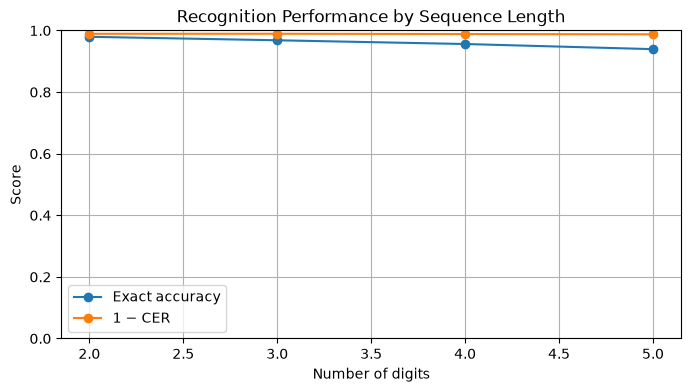

In [30]:
plt.figure(figsize=(8, 4))

plt.plot(
    length_performance_df[
        "sequence_length"
    ],
    length_performance_df[
        "exact_accuracy"
    ],
    marker="o",
    label="Exact accuracy"
)

plt.plot(
    length_performance_df[
        "sequence_length"
    ],
    1 - length_performance_df[
        "character_error_rate"
    ],
    marker="o",
    label="1 − CER"
)

plt.title("Recognition Performance by Sequence Length")
plt.xlabel("Number of digits")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

## Sequence length analysis 

Performance by sequence length was:

| Digits | Sequences | Exact accuracy | CER | Length accuracy | Mean edit distance |
|---:|---:|---:|---:|---:|---:|
| 2 | 1,076 | 0.9796 | 0.0107 | 0.9972 | 0.0214 |
| 3 | 976 | 0.9682 | 0.0106 | 0.9980 | 0.0318 |
| 4 | 957 | 0.9561 | 0.0115 | 0.9958 | 0.0460 |
| 5 | 991 | 0.9395 | 0.0123 | 0.9980 | 0.0616 |

Two-digit sequences were the easiest, with exact accuracy of 97.96%.

Five-digit sequences were the hardest, with exact accuracy of 93.95%.

Exact accuracy declined more noticeably than CER as sequence length increased. This is expected because longer strings provide more opportunities for at least one character error.

Length accuracy remained above 99.5% for every sequence length. The decrease in exact accuracy was therefore driven mainly by occasional digit recognition errors rather than failure to infer how many digits were present.

In [31]:
repeat_performance_df = (
    test_prediction_df
    .groupby(
        "contains_adjacent_repeat"
    )
    .agg(
        sequences=(
            "true_text",
            "size"
        ),
        exact_accuracy=(
            "exact_match",
            "mean"
        ),
        mean_edit_distance=(
            "edit_distance",
            "mean"
        ),
        deletion_rate=(
            "deletion",
            "mean"
        )
    )
    .rename(index={
        False:
            "No adjacent repeat",
        True:
            "Contains adjacent repeat"
    })
)

repeat_performance_df

,sequences,exact_accuracy,mean_edit_distance,deletion_rate
contains_adjacent_repeat,,,,
No adjacent repeat,3109,0.965905,0.034738,0.001608
Contains adjacent repeat,891,0.945006,0.057239,0.002245


## Repeated digit analysis 

Test sequences were divided into:

- 3,109 sequences without adjacent repeated digits
- 891 sequences containing at least one adjacent repeat

Results were:

| Sequence type | Exact accuracy | Mean edit distance | Mean deletions per sequence |
|---|---:|---:|---:|
| No adjacent repeat | 0.9659 | 0.0347 | 0.0016 |
| Contains adjacent repeat | 0.9450 | 0.0572 | 0.0022 |

Adjacent repeated digits reduced exact accuracy by approximately 2.09 percentage points.

They also produced a higher mean edit distance and slightly more deletions.

The effect was noticeable but not severe. The model successfully recognised most repeated-digit sequences, showing that it generally learned to place blank activations between identical neighbouring digits so that they would not collapse into one output.

In [32]:
edit_summary_df = pd.DataFrame({
    "edit_type": [
        "Substitutions",
        "Insertions",
        "Deletions"
    ],
    "count": [
        test_metrics[
            "substitutions"
        ],
        test_metrics[
            "insertions"
        ],
        test_metrics[
            "deletions"
        ]
    ]
})

edit_summary_df

,edit_type,count
0,Substitutions,148
1,Insertions,4
2,Deletions,7


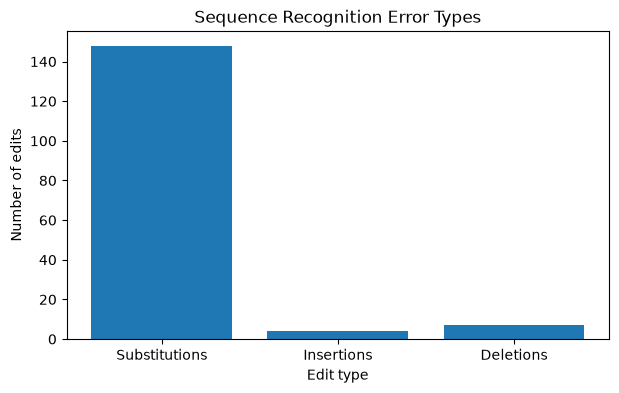

In [33]:
plt.figure(figsize=(7, 4))

plt.bar(
    edit_summary_df[
        "edit_type"
    ],
    edit_summary_df["count"]
)

plt.title("Sequence Recognition Error Types")
plt.xlabel("Edit type")
plt.ylabel("Number of edits")
plt.show()

## Edit type analysis 

The model produced 159 total character edits:

- Substitutions: 148
- Insertions: 4
- Deletions: 7

Substitutions accounted for approximately 93% of all edits.

This indicates that the model usually inferred the correct sequence length and character positions but occasionally confused one handwritten digit with another.

Insertions and deletions were extremely rare. The CTC alignment and greedy decoding process therefore handled segmentation and output length much more reliably than character identity.

The main remaining problem was visual ambiguity between handwritten digit classes rather than sequence alignment.

In [34]:
def plot_sequence_predictions(
    dataset,
    prediction_df,
    indices,
    title
):
    figure, axes = plt.subplots(
        2,
        4,
        figsize=(14, 5)
    )

    for axis, index in zip(
        axes.flatten(),
        indices
    ):
        image, _, _ = dataset[
            int(index)
        ]

        prediction_row = (
            prediction_df.iloc[
                int(index)
            ]
        )

        axis.imshow(
            image.squeeze(),
            cmap="gray",
            vmin=0,
            vmax=1,
            aspect="auto"
        )

        axis.set_title(
            f"True: "
            f"{prediction_row['true_text']}\n"
            f"Pred: "
            f"{prediction_row['predicted_text']}"
        )

        axis.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

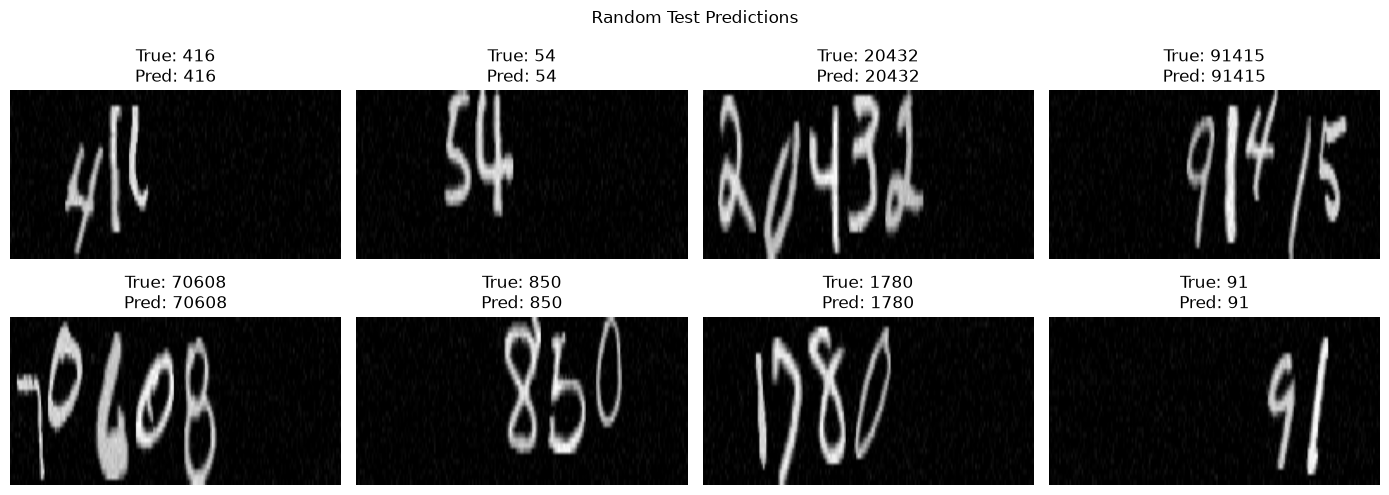

In [35]:
visual_rng = np.random.default_rng(
    RANDOM_STATE
)

random_prediction_indices = (
    visual_rng.choice(
        len(test_dataset),
        size=8,
        replace=False
    )
)

plot_sequence_predictions(
    test_dataset,
    test_prediction_df,
    random_prediction_indices,
    "Random Test Predictions"
)

## Random prediction 

All eight randomly selected test sequences were predicted exactly correctly.

The displayed examples included:

- `416`
- `54`
- `20432`
- `91415`
- `70608`
- `850`
- `1780`
- `91`

The model handled sequences from two to five digits, different starting positions, unequal digit widths, and varied handwriting styles.

It also predicted the correct output length in every displayed example.

These examples illustrate that the model did not require fixed character slots. It successfully read each sequence from left to right despite large unused regions of the canvas.

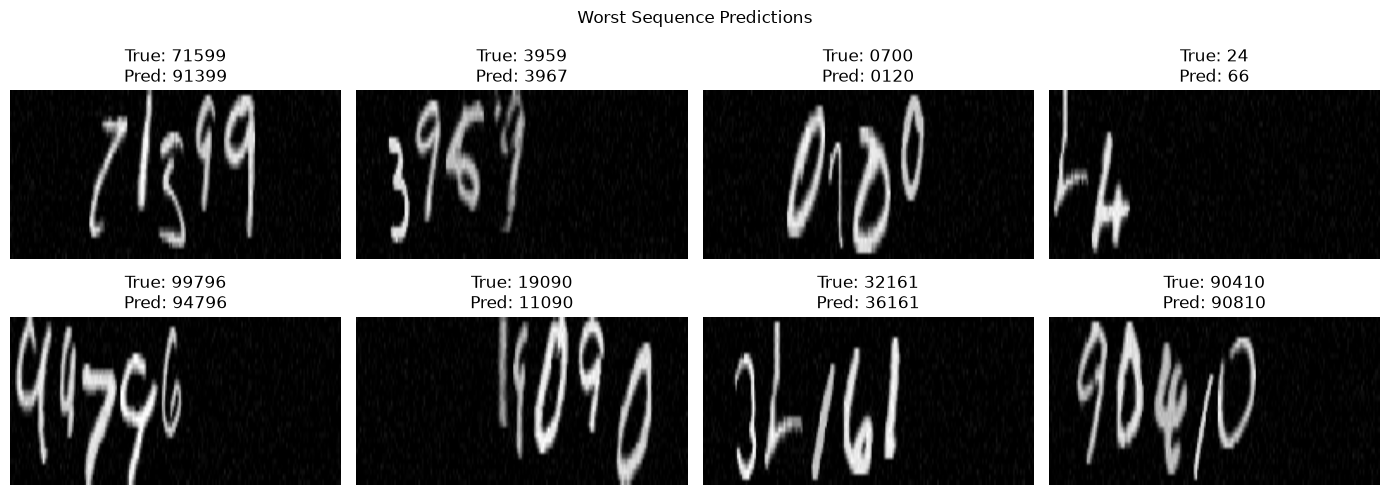

In [36]:
worst_prediction_indices = (
    test_prediction_df
    .sort_values(
        [
            "edit_distance",
            "true_length"
        ],
        ascending=False
    )
    .head(8)[
        "dataset_index"
    ]
    .to_numpy()
)

plot_sequence_predictions(
    test_dataset,
    test_prediction_df,
    worst_prediction_indices,
    "Worst Sequence Predictions"
)

In [37]:
test_prediction_df.sort_values(
    [
        "edit_distance",
        "true_length"
    ],
    ascending=False
).head(20)[
    [
        "dataset_index",
        "true_text",
        "predicted_text",
        "true_length",
        "predicted_length",
        "edit_distance",
        "substitution",
        "insertion",
        "deletion",
        "contains_adjacent_repeat"
    ]
]

,dataset_index,true_text,predicted_text,true_length,predicted_length,edit_distance,substitution,insertion,deletion,contains_adjacent_repeat
1560,1560,71599,91399,5,5,2,2,0,0,True
3259,3259,3959,3967,4,4,2,2,0,0,False
3605,3605,0700,0120,4,4,2,2,0,0,True
1704,1704,24,66,2,2,2,2,0,0,False
35,35,99796,94796,5,5,1,1,0,0,True
110,110,19090,11090,5,5,1,1,0,0,False
111,111,32161,36161,5,5,1,1,0,0,False
120,120,90410,90810,5,5,1,1,0,0,False
174,174,88434,88454,5,5,1,1,0,0,True
182,182,83559,83539,5,5,1,1,0,0,True


## Failure analysis 

The most severe displayed failures still involved only two substitutions.

Examples included:

- `71599` predicted as `91399`
- `3959` predicted as `3967`
- `0700` predicted as `0120`
- `24` predicted as `66`

The remaining top errors usually contained only one incorrect digit.

Common visual confusions included handwritten forms resembling:

- 5 and 3
- 9 and 7
- 7 and 1
- 4 and 6
- 0 and other rounded digits

Several difficult examples contained adjacent repeated digits, but repeated characters were not the only source of failure.

The displayed worst cases preserved the correct sequence length and contained no insertions or deletions. This agrees with the overall error totals: recognition errors were overwhelmingly substitutions rather than alignment failures.

In [38]:
correct_example_index = int(
    test_prediction_df[
        test_prediction_df[
            "exact_match"
        ]
    ].iloc[0][
        "dataset_index"
    ]
)

alignment_image, _, alignment_text = (
    test_dataset[
        correct_example_index
    ]
)

print(
    "Selected target:",
    alignment_text
)

Selected target: 93504


In [39]:
model.eval()

with torch.no_grad():
    alignment_logits = model(
        alignment_image
        .unsqueeze(0)
        .to(device)
    )

    alignment_probabilities = (
        torch.softmax(
            alignment_logits[:, 0, :],
            dim=1
        )
        .cpu()
        .numpy()
        .T
    )

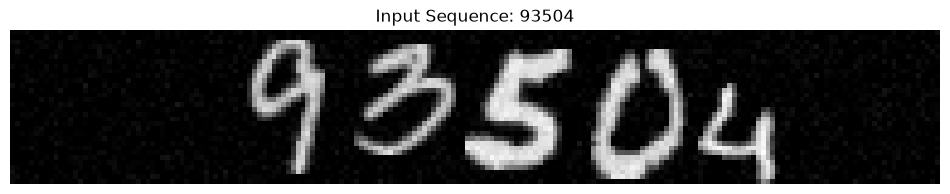

In [40]:
plt.figure(figsize=(12, 2))

plt.imshow(
    alignment_image.squeeze(),
    cmap="gray",
    vmin=0,
    vmax=1,
    aspect="auto"
)

plt.title(
    f"Input Sequence: {alignment_text}"
)

plt.axis("off")
plt.show()

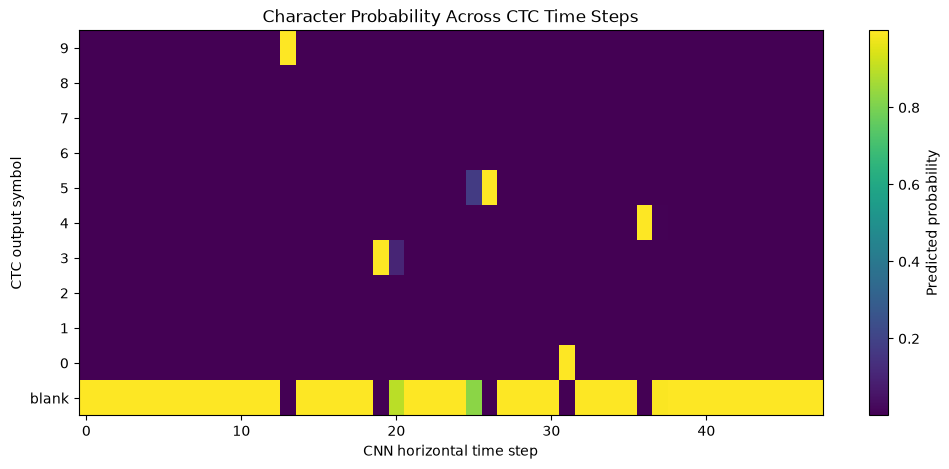

In [41]:
ctc_label_names = [
    "blank",
    "0",
    "1",
    "2",
    "3",
    "4",
    "5",
    "6",
    "7",
    "8",
    "9"
]

plt.figure(figsize=(12, 5))

plt.imshow(
    alignment_probabilities,
    aspect="auto",
    origin="lower"
)

plt.yticks(
    range(
        len(ctc_label_names)
    ),
    ctc_label_names
)

plt.xlabel("CNN horizontal time step")
plt.ylabel("CTC output symbol")

plt.title(
    "Character Probability Across CTC Time Steps"
)

plt.colorbar(
    label="Predicted probability"
)

plt.show()

## CTC alignment 

The selected correctly recognised sequence was:

`93504`

The probability heatmap showed five character activations in the correct left-to-right order:

1. Digit 9
2. Digit 3
3. Digit 5
4. Digit 0
5. Digit 4

Blank probability dominated most of the 48 horizontal time steps, particularly before, after, and between character activations.

Each digit became highly probable only within a small horizontal region corresponding to its position in the image.

This demonstrates that the model learned an implicit monotonic alignment between image regions and output characters. No frame-level or character-boundary labels were supplied during training.

CTC was free to use several time steps for one digit and blank symbols between digits before collapsing the frame-level path into the final sequence.

In [42]:
robustness_datasets = {
    "Tight spacing":
        MultiDigitMNISTDataset(
            source_dataset=test_mnist,
            number_of_sequences=2_000,
            minimum_spacing=0,
            maximum_spacing=1,
            noise_standard_deviation=0.03,
            base_seed=50_000
        ),

    "Standard spacing":
        MultiDigitMNISTDataset(
            source_dataset=test_mnist,
            number_of_sequences=2_000,
            minimum_spacing=2,
            maximum_spacing=6,
            noise_standard_deviation=0.03,
            base_seed=50_000
        ),

    "Wide spacing":
        MultiDigitMNISTDataset(
            source_dataset=test_mnist,
            number_of_sequences=2_000,
            minimum_spacing=10,
            maximum_spacing=14,
            noise_standard_deviation=0.03,
            base_seed=50_000
        ),

    "High noise":
        MultiDigitMNISTDataset(
            source_dataset=test_mnist,
            number_of_sequences=2_000,
            minimum_spacing=2,
            maximum_spacing=6,
            noise_standard_deviation=0.10,
            base_seed=50_000
        )
}

In [43]:
robustness_rows = []

for condition_name, condition_dataset in (
    robustness_datasets.items()
):
    condition_loader = DataLoader(
        condition_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=
            ctc_collate_function,
        num_workers=0
    )

    condition_result = (
        evaluate_ctc_model(
            model,
            condition_loader
        )
    )

    condition_metrics = (
        condition_result["metrics"]
    )

    robustness_rows.append({
        "condition":
            condition_name,

        "exact_sequence_accuracy":
            condition_metrics[
                "exact_sequence_accuracy"
            ],

        "character_error_rate":
            condition_metrics[
                "character_error_rate"
            ],

        "length_accuracy":
            condition_metrics[
                "length_accuracy"
            ],

        "mean_edit_distance":
            condition_metrics[
                "mean_edit_distance"
            ]
    })

robustness_df = pd.DataFrame(
    robustness_rows
)

robustness_df

,condition,exact_sequence_accuracy,character_error_rate,length_accuracy,mean_edit_distance
0,Tight spacing,0.8460,0.048592,0.9030,0.1700
1,Standard spacing,0.9635,0.010576,0.9990,0.0370
2,Wide spacing,0.9670,0.009576,0.9985,0.0335
3,High noise,0.8390,0.049164,0.9910,0.1720


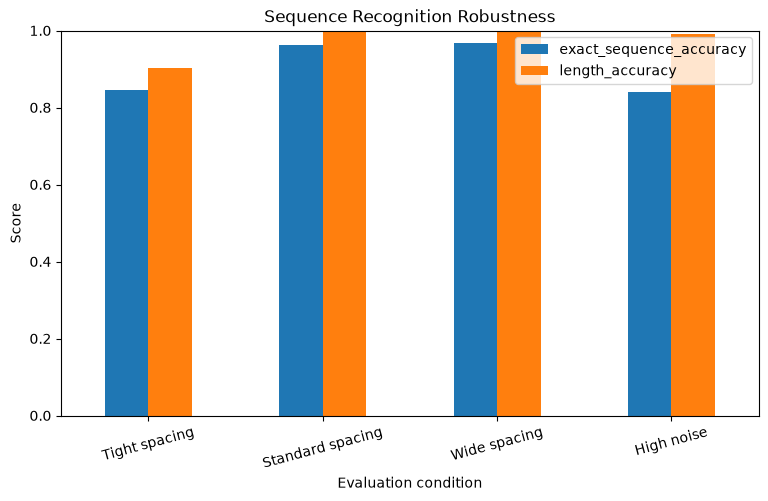

In [44]:
robustness_df.set_index(
    "condition"
)[
    [
        "exact_sequence_accuracy",
        "length_accuracy"
    ]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Sequence Recognition Robustness"
)

plt.xlabel("Evaluation condition")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

## Robustness analysis 

Results under different visual conditions were:

| Condition | Exact accuracy | CER | Length accuracy | Mean edit distance |
|---|---:|---:|---:|---:|
| Tight spacing | 0.8460 | 0.0486 | 0.9030 | 0.1700 |
| Standard spacing | 0.9635 | 0.0106 | 0.9990 | 0.0370 |
| Wide spacing | 0.9670 | 0.0096 | 0.9985 | 0.0335 |
| High noise | 0.8390 | 0.0492 | 0.9910 | 0.1720 |

### Wide spacing

Wide spacing produced slightly better exact accuracy than the standard condition:

- Standard: 0.9635
- Wide: 0.9670

The model therefore tolerated gaps wider than those used during training.

### Tight spacing

Tight spacing reduced exact accuracy to 0.8460 and length accuracy to 0.9030.

The large drop in length accuracy suggests that neighbouring digits sometimes appeared connected and were merged or aligned incorrectly.

### High noise

High noise was the most difficult condition by exact accuracy:

- Exact accuracy: 0.8390
- CER: 0.0492

However, length accuracy remained 0.9910. The model usually knew how many digits were present but more frequently confused their identities.

Tight spacing therefore affected both character recognition and sequence segmentation, while high noise mainly damaged visual character recognition.

In [45]:
best_length_row = (
    length_performance_df
    .sort_values(
        "exact_accuracy",
        ascending=False
    )
    .iloc[0]
)

weakest_length_row = (
    length_performance_df
    .sort_values(
        "exact_accuracy",
        ascending=True
    )
    .iloc[0]
)

final_summary_df = pd.DataFrame({
    "metric": [
        "Training sequences",
        "Validation sequences",
        "Test sequences",
        "Baseline exact accuracy",
        "Baseline CER",
        "Test exact accuracy",
        "Test CER",
        "Test length accuracy",
        "Mean edit distance",
        "Best sequence length",
        "Weakest sequence length"
    ],
    "value": [
        len(training_dataset),
        len(validation_dataset),
        len(test_dataset),
        baseline_metrics[
            "exact_sequence_accuracy"
        ],
        baseline_metrics[
            "character_error_rate"
        ],
        test_metrics[
            "exact_sequence_accuracy"
        ],
        test_metrics[
            "character_error_rate"
        ],
        test_metrics[
            "length_accuracy"
        ],
        test_metrics[
            "mean_edit_distance"
        ],
        int(
            best_length_row[
                "sequence_length"
            ]
        ),
        int(
            weakest_length_row[
                "sequence_length"
            ]
        )
    ]
})

final_summary_df

,metric,value
0,Training sequences,15000.000000
1,Validation sequences,3000.000000
2,Test sequences,4000.000000
3,Baseline exact accuracy,0.003500
4,Baseline CER,0.884080
5,Test exact accuracy,0.961250
6,Test CER,0.011469
7,Test length accuracy,0.997250
8,Mean edit distance,0.039750
9,Best sequence length,2.000000
